# Setup

In [1]:
import pandas as pd
from scipy import stats

In [2]:
import seaborn as sns

In [3]:
import numpy as np

In [4]:
from ydata_profiling import ProfileReport

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
from statsmodels.multivariate.manova import MANOVA

# Laod Data

In [7]:
filename = './Results/output02.csv'
df = pd.read_csv(filename, header=0, index_col=0)
df.head()

,IOS_score,IOS_group,Adj_cosine,Adj_euclidean,Adj_manhattan,Verb_cosine,Verb_euclidean,Verb_manhattan,Noun_cosine,Noun_euclidean,Noun_manhattan
MID,,,,,,,,,,,
2.0,5.0,HighIOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5.0,2.0,LowIOS,NaN,NaN,NaN,0.933851,0.344139,1.932724,0.882830,0.469692,2.609289
7.0,5.0,HighIOS,0.489526,0.77925,4.465907,0.826740,0.433577,2.556113,0.035336,1.129285,6.480907
8.0,1.0,LowIOS,NaN,NaN,NaN,NaN,NaN,NaN,0.397660,1.097579,6.200497
11.0,2.0,LowIOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.isnull().sum()

IOS_score           0
IOS_group          75
Adj_cosine        218
Adj_euclidean     218
Adj_manhattan     218
Verb_cosine       182
Verb_euclidean    182
Verb_manhattan    182
Noun_cosine       187
Noun_euclidean    187
Noun_manhattan    187
dtype: int64

# Data Profiling

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

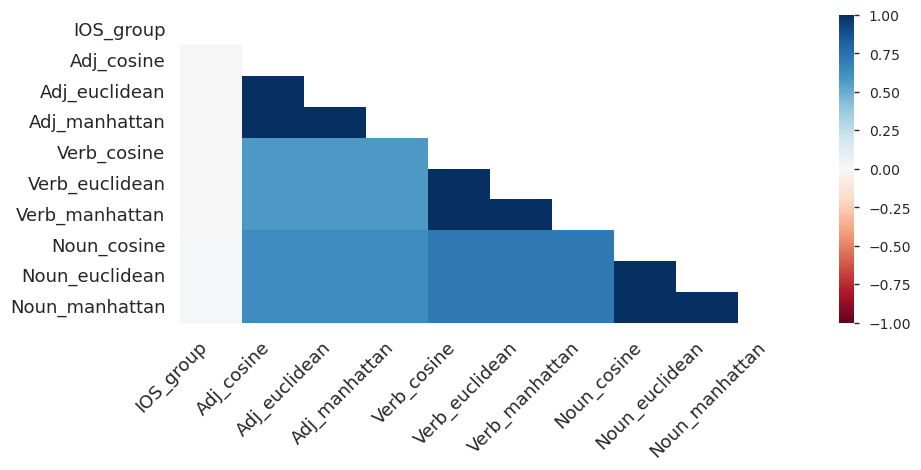

In [9]:
ProfileReport(df, title="Profiling Report")

# Descriptive Statistics

## IOS_group

In [10]:
# IOS_group
df["IOS_group"].describe().T

count         404
unique          2
top       HighIOS
freq          204
Name: IOS_group, dtype: object

In [11]:
# Value counts
df["IOS_group"].value_counts()

IOS_group
HighIOS    204
LowIOS     200
Name: count, dtype: int64

## Cosine Similarity of Adjectives

In [12]:
# Describe
df["Adj_cosine"].describe().T

count    261.000000
mean       0.649910
std        0.229282
min        0.076291
25%        0.496151
50%        0.690595
75%        0.810991
max        1.000000
Name: Adj_cosine, dtype: float64

## Cosine Similarity of Verbs

In [13]:
# Describe
df["Verb_cosine"].describe().T

count    297.000000
mean       0.677153
std        0.221653
min       -0.045727
25%        0.560761
50%        0.734769
75%        0.842901
max        1.000000
Name: Verb_cosine, dtype: float64

## Cosine Similarity of Nouns

In [14]:
# Describe
df["Noun_cosine"].describe().T

count    292.000000
mean       0.642074
std        0.214614
min        0.032985
25%        0.520943
50%        0.692283
75%        0.798638
max        1.000000
Name: Noun_cosine, dtype: float64

# Confirmatory Analyses: MANOVA

## Cosine Similarity

In [15]:
df_cosine = df[['IOS_group', 'Adj_cosine', 'Verb_cosine', 'Noun_cosine']]
df_cosine.head()

,IOS_group,Adj_cosine,Verb_cosine,Noun_cosine
MID,,,,
2.0,HighIOS,NaN,NaN,NaN
5.0,LowIOS,NaN,0.933851,0.882830
7.0,HighIOS,0.489526,0.826740,0.035336
8.0,LowIOS,NaN,NaN,0.397660
11.0,LowIOS,NaN,NaN,NaN


In [16]:
df_cosine.groupby('IOS_group').count()

,Adj_cosine,Verb_cosine,Noun_cosine
IOS_group,,,
HighIOS,109,120,118
LowIOS,111,130,129


In [17]:
df_cosine.groupby('IOS_group').agg([np.mean, np.std]).T

/tmp/ipykernel_955/1711250542.py:1: FutureWarning: The provided callable <function mean at 0x7f8a067e9760> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_cosine.groupby('IOS_group').agg([np.mean, np.std]).T
/tmp/ipykernel_955/1711250542.py:1: FutureWarning: The provided callable <function std at 0x7f8a067e9940> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  df_cosine.groupby('IOS_group').agg([np.mean, np.std]).T
/tmp/ipykernel_955/1711250542.py:1: FutureWarning: The provided callable <function mean at 0x7f8a067e9760> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_cosine.groupby('IOS_group').agg([np.mean, np.

IOS_group          HighIOS    LowIOS
Adj_cosine  mean  0.660472  0.630820
            std   0.226336  0.226550
Verb_cosine mean  0.694594  0.673359
            std   0.219585  0.215920
Noun_cosine mean  0.669466  0.630303
            std   0.220079  0.205411

In [20]:
# MANOVA for Adj_cosine, Verb_cosine, Noun_cosine
maov_cosine = MANOVA.from_formula('Adj_cosine + Verb_cosine + Noun_cosine ~ IOS_group', data=df_cosine)
print(maov_cosine.mv_test())

                   Multivariate linear model
                                                               
---------------------------------------------------------------
       Intercept         Value  Num DF  Den DF  F Value  Pr > F
---------------------------------------------------------------
          Wilks' lambda  0.0873 3.0000 177.0000 617.1687 0.0000
         Pillai's trace  0.9127 3.0000 177.0000 617.1687 0.0000
 Hotelling-Lawley trace 10.4605 3.0000 177.0000 617.1687 0.0000
    Roy's greatest root 10.4605 3.0000 177.0000 617.1687 0.0000
---------------------------------------------------------------
                                                               
---------------------------------------------------------------
         IOS_group        Value  Num DF  Den DF  F Value Pr > F
---------------------------------------------------------------
            Wilks' lambda 0.9794 3.0000 177.0000  1.2434 0.2955
           Pillai's trace 0.0206 3.0000 177.0000  1.2434 0.

/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.u

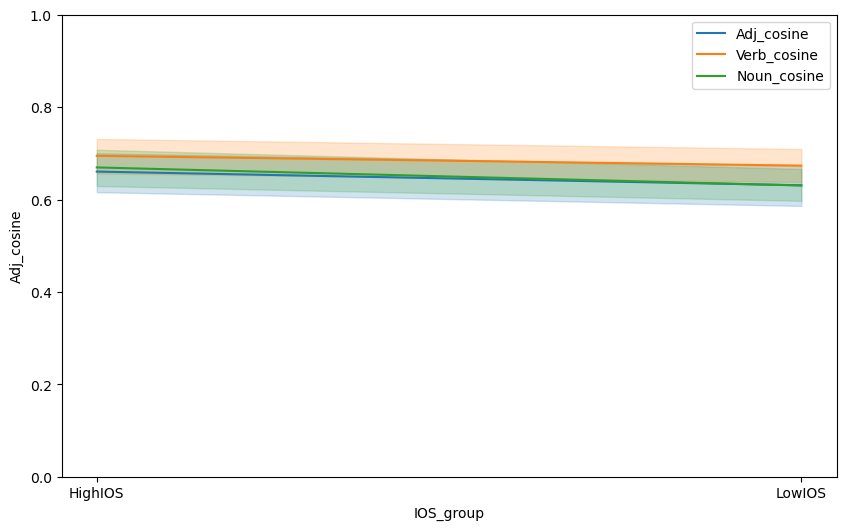

In [21]:
# Create a line plot of Adj_cosine, Verb_cosine, Noun_cosine
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df_cosine, x="IOS_group", y="Adj_cosine", label="Adj_cosine")
sns.lineplot(data=df_cosine, x="IOS_group", y="Verb_cosine", label="Verb_cosine") 
sns.lineplot(data=df_cosine, x="IOS_group", y="Noun_cosine", label="Noun_cosine")
ax.set_ylim(0, 1)
plt.show()

## Euclidean Similarity

In [25]:
df_euclidean = df[['IOS_group', 'Adj_euclidean', 'Verb_euclidean', 'Noun_euclidean']]
df_euclidean.head()

,IOS_group,Adj_euclidean,Verb_euclidean,Noun_euclidean
MID,,,,
2.0,HighIOS,NaN,NaN,NaN
5.0,LowIOS,NaN,0.344139,0.469692
7.0,HighIOS,0.77925,0.433577,1.129285
8.0,LowIOS,NaN,NaN,1.097579
11.0,LowIOS,NaN,NaN,NaN


In [32]:
df_euclidean.groupby('IOS_group').count()

,Adj_euclidean,Verb_euclidean,Noun_euclidean
IOS_group,,,
HighIOS,109,120,118
LowIOS,111,130,129


In [34]:
df_euclidean.groupby('IOS_group').agg([np.mean, np.std]).T

/tmp/ipykernel_906/4009587361.py:1: FutureWarning: The provided callable <function mean at 0x7f4ce41f1580> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_euclidean.groupby('IOS_group').agg([np.mean, np.std]).T
/tmp/ipykernel_906/4009587361.py:1: FutureWarning: The provided callable <function std at 0x7f4ce41f1760> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  df_euclidean.groupby('IOS_group').agg([np.mean, np.std]).T
/tmp/ipykernel_906/4009587361.py:1: FutureWarning: The provided callable <function mean at 0x7f4ce41f1580> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_euclidean.groupby('IOS_group').agg([np.

IOS_group             HighIOS    LowIOS
Adj_euclidean  mean  0.614278  0.643139
               std   0.312642  0.285516
Verb_euclidean mean  0.522012  0.543736
               std   0.260579  0.271083
Noun_euclidean mean  0.550238  0.596330
               std   0.266366  0.244242

In [27]:
# MANOVA for Adj_euclidean, Verb_euclidean, Noun_euclidean
maov_euclidean = MANOVA.from_formula('Adj_euclidean + Verb_euclidean + Noun_euclidean ~ IOS_group', data=df_euclidean)
print(maov_euclidean.mv_test())

                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept        Value  Num DF  Den DF  F Value  Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.1750 3.0000 177.0000 278.1171 0.0000
         Pillai's trace 0.8250 3.0000 177.0000 278.1171 0.0000
 Hotelling-Lawley trace 4.7138 3.0000 177.0000 278.1171 0.0000
    Roy's greatest root 4.7138 3.0000 177.0000 278.1171 0.0000
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
        IOS_group        Value  Num DF  Den DF  F Value Pr > F
--------------------------------------------------------------
           Wilks' lambda 0.9825 3.0000 177.0000  1.0496 0.3720
          Pillai's trace 0.0175 3.0000 177.0000  1.0496 0.3720
  Hotelling

/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.u

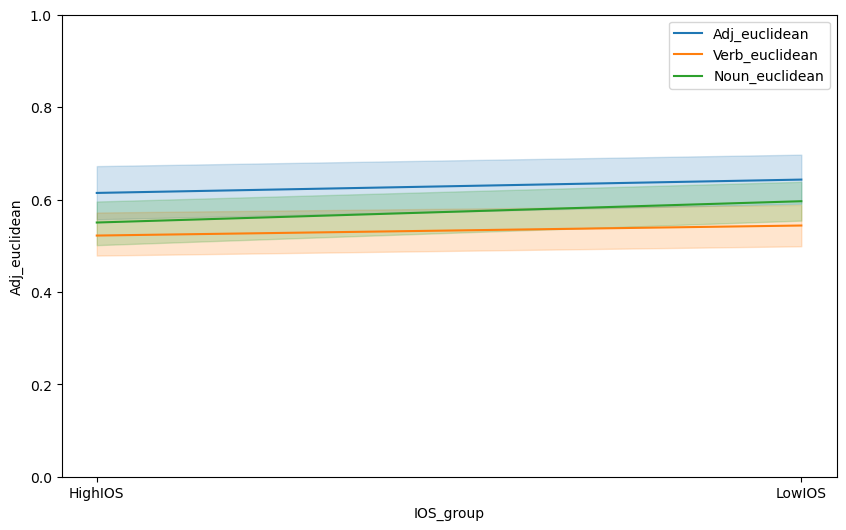

In [28]:
# Create a line plot of Adj_euclidean, Verb_euclidean, Noun_euclidean
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df_euclidean, x="IOS_group", y="Adj_euclidean", label="Adj_euclidean")
sns.lineplot(data=df_euclidean, x="IOS_group", y="Verb_euclidean", label="Verb_euclidean")
sns.lineplot(data=df_euclidean, x="IOS_group", y="Noun_euclidean", label="Noun_euclidean")
ax.set_ylim(0, 1)
plt.show()

## Manhatan Similarity

In [29]:
df_manhattan = df[['IOS_group', 'Adj_manhattan', 'Verb_manhattan', 'Noun_manhattan']]
df_manhattan.head()

,IOS_group,Adj_manhattan,Verb_manhattan,Noun_manhattan
MID,,,,
2.0,HighIOS,NaN,NaN,NaN
5.0,LowIOS,NaN,1.932724,2.609289
7.0,HighIOS,4.465907,2.556113,6.480907
8.0,LowIOS,NaN,NaN,6.200497
11.0,LowIOS,NaN,NaN,NaN


In [36]:
df_manhattan.groupby('IOS_group').count()

,Adj_manhattan,Verb_manhattan,Noun_manhattan
IOS_group,,,
HighIOS,109,120,118
LowIOS,111,130,129


In [37]:
df_manhattan.groupby('IOS_group').agg([np.mean, np.std]).T

/tmp/ipykernel_906/2313590957.py:1: FutureWarning: The provided callable <function mean at 0x7f4ce41f1580> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_manhattan.groupby('IOS_group').agg([np.mean, np.std]).T
/tmp/ipykernel_906/2313590957.py:1: FutureWarning: The provided callable <function std at 0x7f4ce41f1760> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  df_manhattan.groupby('IOS_group').agg([np.mean, np.std]).T
/tmp/ipykernel_906/2313590957.py:1: FutureWarning: The provided callable <function mean at 0x7f4ce41f1580> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df_manhattan.groupby('IOS_group').agg([np.

IOS_group             HighIOS    LowIOS
Adj_manhattan  mean  3.502106  3.671181
               std   1.794008  1.632767
Verb_manhattan mean  2.943682  3.077155
               std   1.464731  1.513692
Noun_manhattan mean  3.122850  3.388771
               std   1.508720  1.411199

In [38]:
# MANOVA for Adj_manhattan, Verb_manhattan, Noun_manhattan
maov_manhattan = MANOVA.from_formula('Adj_manhattan + Verb_manhattan + Noun_manhattan ~ IOS_group', data=df_manhattan)
print(maov_manhattan.mv_test())

                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept        Value  Num DF  Den DF  F Value  Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.1742 3.0000 177.0000 279.6760 0.0000
         Pillai's trace 0.8258 3.0000 177.0000 279.6760 0.0000
 Hotelling-Lawley trace 4.7403 3.0000 177.0000 279.6760 0.0000
    Roy's greatest root 4.7403 3.0000 177.0000 279.6760 0.0000
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
        IOS_group        Value  Num DF  Den DF  F Value Pr > F
--------------------------------------------------------------
           Wilks' lambda 0.9829 3.0000 177.0000  1.0265 0.3822
          Pillai's trace 0.0171 3.0000 177.0000  1.0265 0.3822
  Hotelling

/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.u

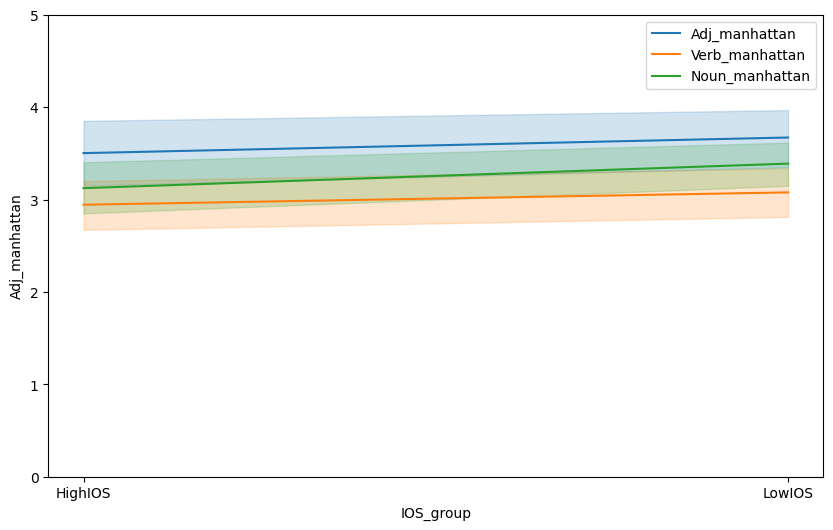

In [41]:
# Create a line plot of Adj_manhattan, Verb_manhattan, Noun_manhattan
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df_manhattan, x="IOS_group", y="Adj_manhattan", label="Adj_manhattan")
sns.lineplot(data=df_manhattan, x="IOS_group", y="Verb_manhattan", label="Verb_manhattan")
sns.lineplot(data=df_manhattan, x="IOS_group", y="Noun_manhattan", label="Noun_manhattan")
ax.set_ylim(0, 5)
plt.show()

# Exploratory Analyses

## 01: a one-tailed independent two-sample t-test
The author had planned:
- sample size: 51 for each group
- alpha: 0.05
- effect size: 0.5
- power: 0.8

In [ ]:
groupH = df[df['IOS_group']=='HighIOS']
groupL = df[df['IOS_group']=='LowIOS']

In [ ]:
len(groupH)

In [ ]:
len(groupL)

### Overlapping Magnitude

In [ ]:
stats.ttest_ind(groupH['Overlap_score'], groupL['Overlap_score'], equal_var=False, alternative='greater') # perform Welch's t-test without assuming equal population variance.

In [ ]:
stats.ttest_ind(groupH['Overlap_score'], groupL['Overlap_score'], equal_var=False, alternative='less') # perform Welch's t-test without assuming equal population variance.

### Euclidean Distance

In [ ]:
stats.ttest_ind(groupH['euclidean_distance'], groupL['euclidean_distance'], equal_var=False, alternative='less')

In [ ]:
stats.ttest_ind(groupH['euclidean_distance'], groupL['euclidean_distance'], equal_var=False, alternative='greater')

### Manhattan Distance

In [ ]:
stats.ttest_ind(groupH['manhattan_distance'], groupL['manhattan_distance'], equal_var=False, alternative='less')

In [ ]:
stats.ttest_ind(groupH['manhattan_distance'], groupL['manhattan_distance'], equal_var=False, alternative='greater')

### Cosine Similarity

In [ ]:
stats.ttest_ind(groupH['cosine_similarity'], groupL['cosine_similarity'], equal_var=False, alternative='greater')

In [ ]:
stats.ttest_ind(groupH['cosine_similarity'], groupL['cosine_similarity'], equal_var=False, alternative='less')

### Post hoc Power Analysis

In [ ]:
print('Num. of group H: ' + str(len(groupH)))
print('Num. of group L: ' + str(len(groupL)))

In [ ]:
def cohens_d(x1, x2):
    n1 = len(x1)
    n2 = len(x2)
    x1_mean = x1.mean()
    x2_mean = x2.mean()
    s1 = x1.std()
    s2 = x2.std()
    s = np.sqrt((n1*np.square(s1) + n2*np.square(s2)) / (n1 + n2))
    d = np.abs(x1_mean - x2_mean) / s
    return d

In [ ]:
euclidean_d = cohens_d(groupH['euclidean_distance'], groupL['euclidean_distance'])
print('Cohen''s d (Euclidean distance): {:.4f}'.format(euclidean_d))
manhattan_d = cohens_d(groupH['manhattan_distance'], groupL['manhattan_distance'])
print('Cohen''s d (Manhattan distance): {:.4f}'.format(manhattan_d))
cosine_d = cohens_d(groupH['cosine_similarity'], groupL['cosine_similarity'])
print('Cohen''s d (Cosine similarity): {:.4f}'.format(cosine_d))

In [ ]:
# Compute post hoc power powered by G*Power
print('Post hoc power (Euclidean distance): {:.4f}'.format(0.2791))
print('Post hoc power (Manhattan distance): {:.4f}'.format(0.2417))
print('Post hoc power (Cosine similarity): {:.4f}'.format(0.4981))

## 02: Spearman's rank correlation coefficient between the IOS scores and the overlapping scores
The author had planned:
- sample size: 119, including participants who rated on the IOS scale as 4
- alpha: 0.05
- effect size: 0.3
- power: 0.93
- two-tailed


### Overlapping score

In [ ]:
df.head(1)

In [ ]:
iosscores = df['IOS_score']
overlapscores = df['Overlap_score']

In [ ]:
res = stats.spearmanr(iosscores, overlapscores)
res

### Euclidean Dsitance

In [ ]:
euclidean_distance = df['euclidean_distance']
res = stats.spearmanr(iosscores, euclidean_distance)
res

### Manhattan Distance

In [ ]:
manhattan_distance = df['manhattan_distance']
res = stats.spearmanr(iosscores, manhattan_distance)
res

### Cosine Similarity

In [ ]:
cosine_similarity = df['cosine_similarity']
res = stats.spearmanr(iosscores, cosine_similarity)
res

### Post hoc Power Analysis

In [ ]:
print('Num. of Sumple of the IOS socre: ' + str(len(iosscores)))
print('Num. of Sumple of the Overlapping socre: ' + str(len(overlapscores)))

Achieved power: 0.23 (H1: rho1 = 0.127)